# Setup

In [ ]:
!pip install -qU llama-index llama-parse openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.4/253.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.7/300.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.3 MB/s eta 0:00:00


`LlamaIndex` – biblioteka do indeksowania i przeszukiwania danych tekstowych dla LLM.

`LlamaParse` – narzędzie do parsowania dokumentów (PDF, Word, HTML) dla AI.

`OpenAI` – SDK do interakcji z modelami GPT, DALL·E, Whisper przez API.

In [ ]:
import nest_asyncio

import os


from llama_index.llms.openai import OpenAI
from llama_index.core import VectorStoreIndex
from IPython.display import Image, Markdown

from google.colab import userdata


from llama_parse import LlamaParse
from llama_index.core.node_parser import MarkdownElementNodeParser

`nest_asyncio` umożliwia zagnieżdżanie pętli asynchronicznych, co jest przydatne przy równoległym wykonywaniu zadań w notebookach Jupyter czy Colab. Działa jak "nakładka" pozwalająca na uruchamianie jednej pętli asynchronicznej wewnątrz drugiej, co normalnie powodowałoby błędy.


`llama_index.llms.openai import OpenAI` pobiera klasę, która służy jako interfejs do modeli językowych OpenAI (np. GPT-3, GPT-4). Ta klasa upraszcza komunikację z API OpenAI.

`llama_index.core import VectorStoreIndex` importuje komponent do tworzenia indeksów wektorowych. Indeksy te przechowują dokumenty w formie wektorów, co umożliwia szybkie wyszukiwanie semantyczne (według znaczenia, a nie tylko słów kluczowych).

`IPython.display import Image, Markdown` dostarcza funkcji do wyświetlania obrazów i tekstu w formacie Markdown w notebookach Jupyter/Colab, co pozwala na bogatsze formatowanie wyników.

`llama_parse import LlamaParse` importuje narzędzie do zaawansowanego przetwarzania i parsowania dokumentów różnych formatów (PDF, DOC, HTML itp.) na ustrukturyzowane dane.

`llama_index.core.node_parser import MarkdownElementNodeParser` pobiera parser, który dzieli dokument Markdown na mniejsze, znaczące fragmenty ("węzły"), co ułatwia ich indeksowanie i wyszukiwanie.

In [ ]:
nest_asyncio.apply()

Ta linia kodu `nest_asyncio.apply()` aktywuje funkcjonalność biblioteki nest_asyncio w bieżącej sesji.

W standardowym Pythonie istnieje pewne ograniczenie - nie można uruchomić jednej pętli asynchronicznej (event loop) wewnątrz innej. Jest to problematyczne w środowiskach takich jak Jupyter Notebook czy Google Colab, ponieważ one same już wykorzystują pętlę zdarzeń do swojego działania.

In [ ]:
class CFG:
    model = "gpt-4o-mini"

os.environ["OPENAI_API_KEY"] = userdata.get("openaivision")

In [ ]:
llamaparse_key = userdata.get('llamaparse')

# Modele

In [ ]:
gpt_llm = OpenAI(model = CFG.model)

In [ ]:
parser = LlamaParse(
    api_key=llamaparse_key,
    result_type="markdown",
)

# Dane

In [ ]:
documents = parser.load_data("/content/BP_Excel.xlsx")

Started parsing the file under job_id 43d7819a-5609-4e00-85aa-5ab4eabb9b25


Ta linia kodu używa wcześniej utworzonego parsera LlamaParse do wczytania i przetworzenia pliku Excel o nazwie "BP_Excel.xlsx", który znajduje się w katalogu "/content/" (standardowa lokalizacja plików w Google Colab).

`documents = parser.load_data("/content/BP_Excel.xlsx")` jest bardzo istotnym elementem przygotowania danych do dalszej analizy. Przeanalizujmy, co dokładnie się dzieje:

1. `/content/BP_Excel.xlsx` - to ścieżka do pliku Excel, który chcemy przetworzyć.

2. `parser.load_data()` - ta metoda wykonuje faktyczną pracę przetwarzania dokumentu. Pod maską dzieje się tu wiele zaawansowanych operacji:
   - Plik Excel jest przesyłany do zdalnych serwerów LlamaParse
   - Serwery analizują strukturę arkusza, rozpoznając tabele, nagłówki, formuły, itp.
   - Zawartość pliku zostaje przekonwertowana na format Markdown (jak zdefiniowaliśmy wcześniej w `result_type="markdown"`)
   - Przetworzony dokument jest zwracany do naszej aplikacji

3. `documents =` - wynik przetwarzania jest przypisywany do zmiennej `documents`. Ta zmienna będzie zawierać przetworzoną zawartość pliku Excel w formie tekstu w formacie Markdown.

In [ ]:
print(documents[3].get_content())

# Summary

|Financial and Operating Information 2020 - 2024                          |           |        |        |        |        |        |        |        |        |        |        |         |        |        |        |        |        |        |        |        |        |        |        |      |      |           |
|-------------------------------------------------------------------------|-----------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|---------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|------|------|-----------|
|Group information                                                        |           |        |        |        |        |        |        |        |        |        |        |         |        |        |        |        |        |        |        |        |        |        |        |      |      |           |
|                                                 

# Recursive retrieval

In [ ]:
node_parser = MarkdownElementNodeParser(llm=gpt_llm, num_workers=4)

Ten wiersz kodu tworzy parser do analizy dokumentów w formacie Markdown, który będzie później wykorzystywany do podziału większych dokumentów na mniejsze fragmenty (węzły) do bardziej precyzyjnego indeksowania i wyszukiwania.

`node_parser = MarkdownElementNodeParser(llm = my_llm, num_workers=4)`

In [ ]:
nodes = node_parser.get_nodes_from_documents(documents[:10])

1it [00:00, 3615.78it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
1it [00:00, 1618.17it/s]
1it [00:00, 2109.81it/s]
1it [00:00, 3527.59it/s]
1it [00:00, 1883.39it/s]
1it [00:00, 3218.96it/s]
1it [00:00, 1610.10it/s]
1it [00:00, 3379.78it/s]


Ta linia kodu wykonuje faktyczne podzielenie dokumentów na mniejsze znaczące fragmenty (węzły) przy użyciu wcześniej utworzonego parsera Markdown.

`nodes = node_parser.get_nodes_from_documents(documents[:10])`

Czym dokładnie są te "węzły"? Wyobraźmy sobie, że każdy węzeł to jak mała karteczka samoprzylepna z fragmentem informacji. Każdy węzeł zawiera:
- Treść tekstową (fragment oryginalnego dokumentu)
- Metadane (informacje o tym, skąd pochodzi ten fragment)
- Unikalne identyfikatory

Proces podziału na węzły jest kluczowy dla późniejszego efektywnego wyszukiwania informacji. Zamiast przeszukiwać całe dokumenty, system może szybko zidentyfikować konkretne węzły, które zawierają odpowiedzi na pytania. Jest to podobne do indeksu w książce - zamiast czytać całą książkę, aby znaleźć konkretną informację, możesz sprawdzić indeks i od razu przejść do właściwej strony.

W kontekście pracy z dużymi modelami językowymi, podział na węzły ma dodatkową zaletę - pozwala na przetwarzanie dokumentów, które przekraczają standardowe limity kontekstu modelu (np. GPT-4o Mini ma limit około 128K tokenów). Dzieląc dokument na mniejsze części, możemy przetwarzać nawet bardzo duże zbiory danych.

In [ ]:
base_nodes, objects = node_parser.get_nodes_and_objects(nodes)

Ta linia kodu `base_nodes, objects = node_parser.get_nodes_and_objects(nodes)` reprezentuje kolejny krok w przetwarzaniu dokumentów, rozdzielając podstawowe węzły od obiektów specjalnych.

Metoda `get_nodes_and_objects()` wykonuje bardziej zaawansowane przetwarzanie niż poprzednia operacja. Podczas gdy `get_nodes_from_documents()` tworzyła węzły z dokumentów, ta metoda dokonuje dodatkowej separacji na dwie kategorie:

1. `base_nodes` - to podstawowe, "zwykłe" węzły tekstowe. Można je postrzegać jako standardowe fragmenty tekstu, które zawierają główną treść dokumentu, taką jak akapity, opisy, czy proste listy. Są one fundamentem naszego indeksu i będą stanowić podstawę do wyszukiwania informacji.

2. `objects` - to specjalne elementy, które parser wykrył w dokumentach, takie jak tabele, wykresy, obrazy lub inne struktury, które nie są zwykłym tekstem. W kontekście dokumentu pochodzącego z Excela jest to szczególnie istotne, ponieważ Excel zawiera wiele strukturalnych elementów, jak tabele z danymi czy wykresy.

Ta separacja jest bardzo ważna z perspektywy efektywnego indeksowania i wyszukiwania. Różne typy zawartości mogą wymagać różnych metod indeksowania i przeszukiwania. Na przykład:

- Tekst może być indeksowany przy użyciu standardowych metod wektoryzacji
- Tabele mogą wymagać specjalnych metod do wyszukiwania wartości w kolumnach
- Wykresy mogą potrzebować specjalnego opisu lub metadanych

In [ ]:

print(objects[3].get_content())

This table presents the financial and operating information of a group from 2020 to 2024, detailing the condensed statement of comprehensive income, including profit or loss for the period, other comprehensive income, and total comprehensive income attributable to shareholders and non-controlling interests.,
with the following table title:
Financial and Operating Information 2020 - 2024,
with the following columns:
- Group information: None
- Condensed group statement of comprehensive income: None
- Profit (loss) for the period: None
- Other comprehensive income: None
- Total comprehensive income: None
- Attributable to: None



## Build Recursive Retrieval Index

In [ ]:
# dump both indexed tables and page text into the vector index
recursive_index = VectorStoreIndex(nodes=base_nodes + objects, llm = gpt_llm)

recursive_query_engine  = recursive_index.as_query_engine(
    similarity_top_k=5, llm= gpt_llm)

Te dwie linie kodu tworzą i konfigurują indeks wektorowy, który będzie służył do wyszukiwania informacji w przetworzonych dokumentach.

W pierwszej linii:
```python
recursive_index = VectorStoreIndex(nodes=base_nodes + objects, llm = gpt_llm)
```

Tworzymy indeks wektorowy, będący sercem systemu wyszukiwania informacji. Wyobraźmy sobie indeks wektorowy jako specjalną bibliotekę, w której każdy fragment tekstu (każdy węzeł) jest przekształcany w długi ciąg liczb (wektor) odzwierciedlający jego znaczenie. Dzięki temu możemy później znajdować podobne fragmenty na podstawie ich "semantycznego sąsiedztwa" - nawet jeśli nie zawierają dokładnie tych samych słów.

Parametr `nodes=base_nodes + objects` oznacza, że do indeksu dodajemy zarówno zwykłe fragmenty tekstu, jak i specjalne obiekty (np. tabele). Operator `+` łączy te dwie listy w jedną. Jest to całościowe podejście, które zapewnia, że wszystkie rodzaje danych mogą być przeszukiwane w jednolity sposób.

Parametr `llm = gpt_llm` określa, który model językowy będzie używany do przekształcania tekstów na wektory oraz do generowania odpowiedzi. Używamy tutaj wcześniej zdefiniowanego modelu GPT-4o Mini.

W drugiej linii:
```python
recursive_query_engine = recursive_index.as_query_engine(
    similarity_top_k=5, llm= gpt_llm)
```

Tworzymy silnik zapytań, który będzie wykorzystywał wcześniej zbudowany indeks. Silnik zapytań to interfejs, przez który będziemy zadawać pytania o zawartość dokumentów.

Parametr `similarity_top_k=5` określa, że podczas wyszukiwania system wybierze 5 najbardziej podobnych fragmentów do zapytania. Jest to kluczowe ustawienie - zbyt mała wartość mogłaby pominąć istotne informacje, a zbyt duża wprowadziłaby szum i nieistotne fragmenty. Pięć to rozsądny kompromis, który zapewnia wystarczająco dużo kontekstu, ale nie przytłacza modelu języka nadmiarem informacji.

Ponowne użycie `llm= gpt_llm` zapewnia, że ten sam model językowy będzie wykorzystywany do analizowania pytań i generowania odpowiedzi.

Nazwa "recursive" (rekurencyjny) w zmiennych sugeruje, że indeks może obsługiwać zagnieżdżone struktury danych lub może rekurencyjnie przeszukiwać powiązane fragmenty tekstu w celu znalezienia pełniejszej odpowiedzi.

Po wykonaniu tych linii mamy gotowy system, który pozwala na zadawanie pytań o zawartość dokumentu Excel w języku naturalnym. System znajdzie najbardziej odpowiednie fragmenty dokumentu i użyje modelu językowego do sformułowania jasnej, spójnej odpowiedzi, która integruje informacje z tych fragmentów.

# Testy

## Q1

In [ ]:
query = "What was the Sales and other operating revenues in 2020?"

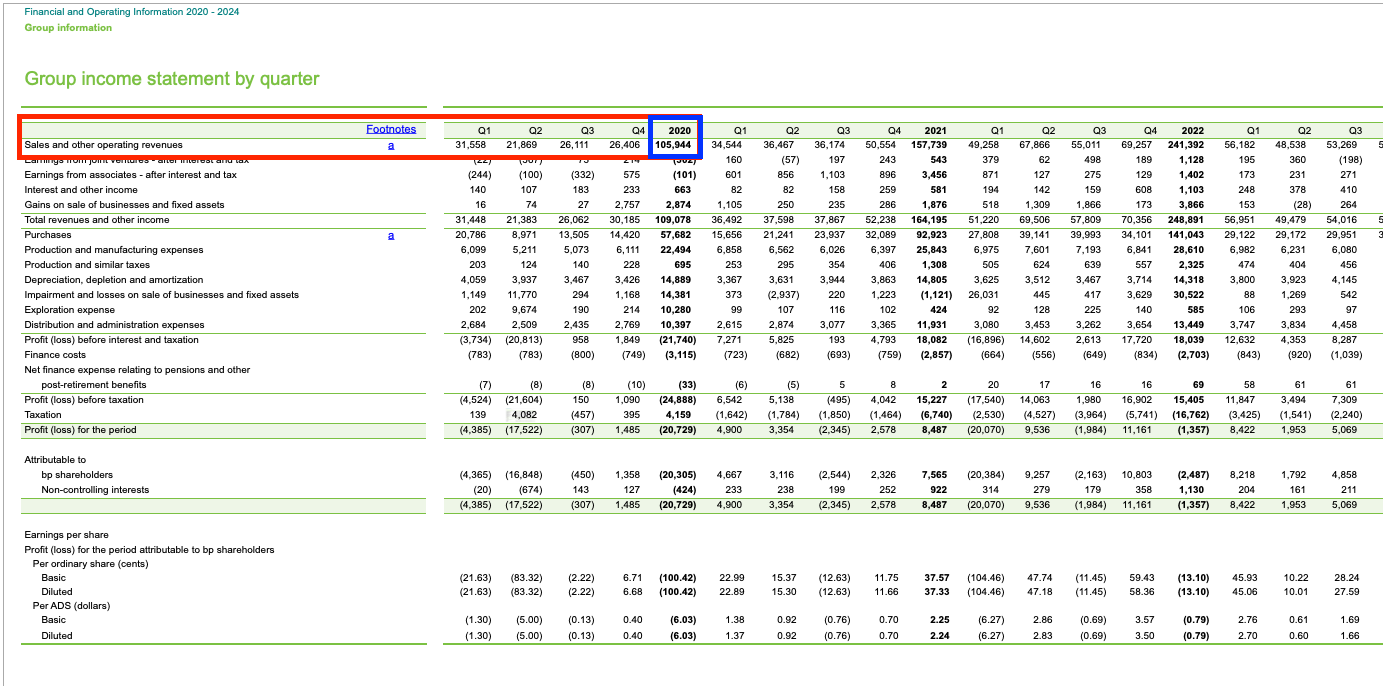

In [ ]:
Image(filename = "/content/query1.png")

A: 105.944 mln USD

In [ ]:
answer = recursive_query_engine.query(query)

Ta linia kodu wykonuje zapytanie do wcześniej przygotowanego silnika wyszukiwania

In [ ]:
display(Markdown(f"{answer}"))

The Sales and other operating revenues in 2020 amounted to 105,944 million.

In [ ]:
# the answer comes from this source node
print(answer.source_nodes[0].get_content())

This table presents the financial and operating information of a group from 2020 to 2024, detailing quarterly income statements, revenues, expenses, profits, and earnings per share.,
with the following table title:
Financial and Operating Information 2020 - 2024,
with the following columns:
- Group information: None
- Group income statement by quarter: None
- Sales and other operating revenues: None
- Earnings from joint ventures - after interest and tax: None
- Earnings from associates - after interest and tax: None
- Interest and other income: None
- Gains on sale of businesses and fixed assets: None
- Total revenues and other income: None
- Purchases: None
- Production and manufacturing expenses: None
- Production and similar taxes: None
- Depreciation, depletion and amortization: None
- Impairment and losses on sale of businesses and fixed assets: None
- Exploration expense: None
- Distribution and administration expenses: None
- Profit (loss) before interest and taxation: None
- F

## Q2

In [ ]:
query = "In which years the Sales and other operating revenues is greater than 150 million?"

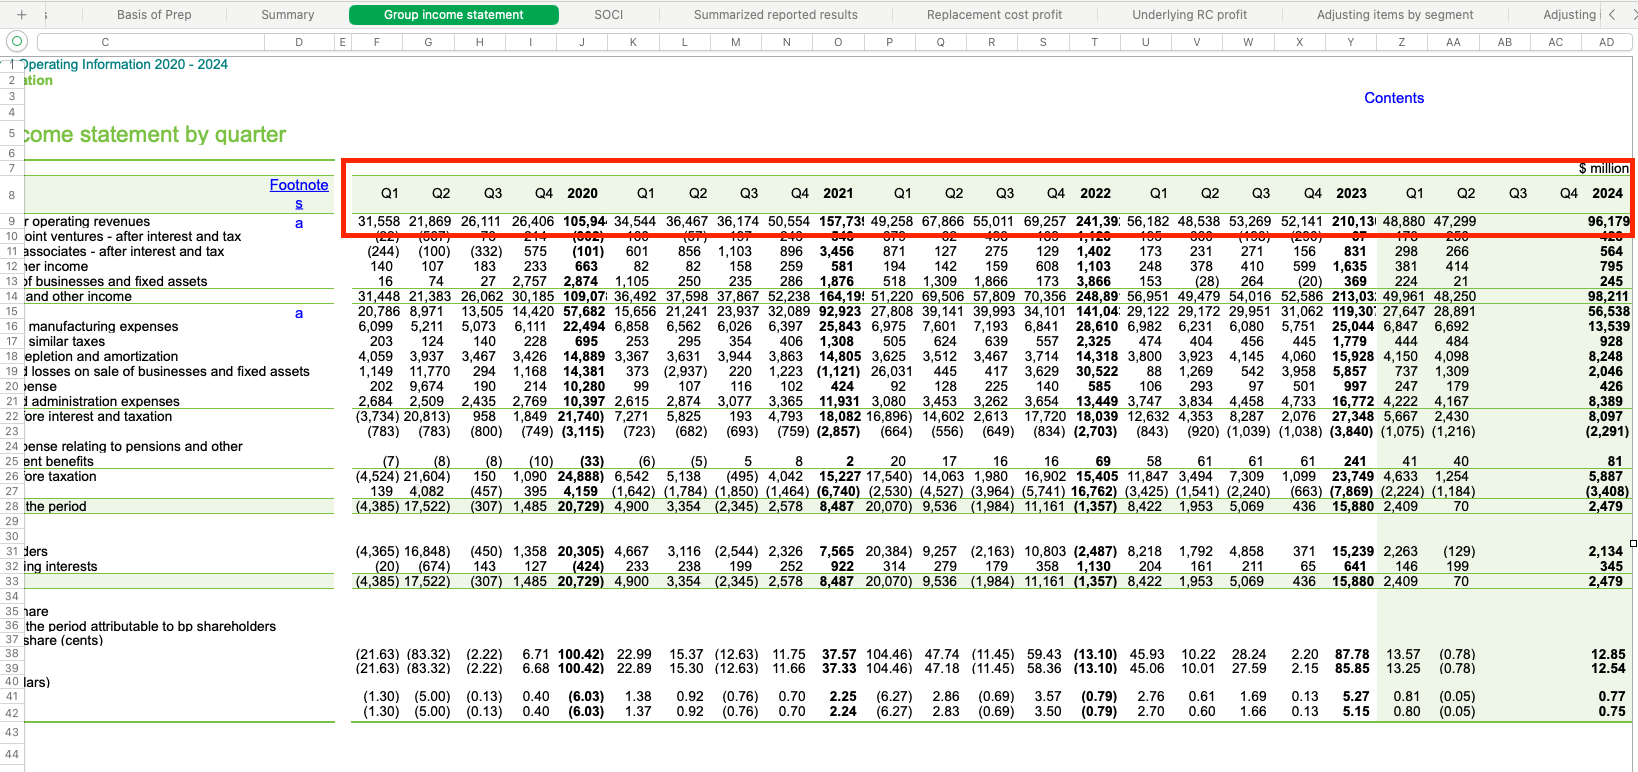

In [ ]:
Image(filename="/content/query2.png")

2021, 2022, 2023

In [ ]:
answer = recursive_query_engine.query(query)

In [ ]:
display(Markdown(f"{answer}"))

The Sales and other operating revenues exceed 150 million in the years 2021, 2022, and 2023.

In [ ]:
print(answer.source_nodes[0].get_content())

Group income statement


## Q3

In [ ]:
query = "Which quarters and years has Total revenues and other income greater than 35 million?"

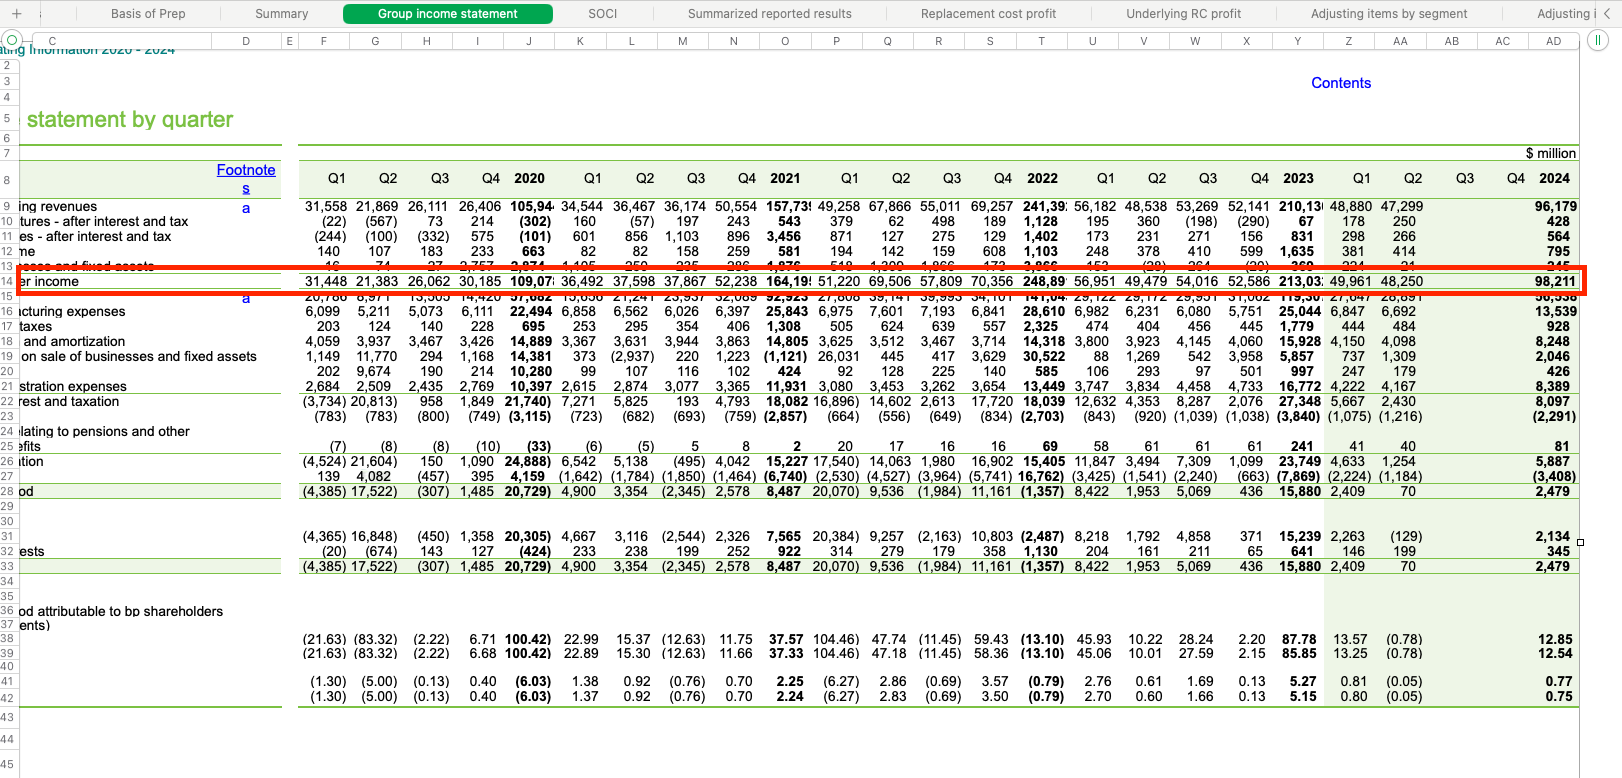

In [ ]:
Image(filename="/content/query3.png")

2021: Q1, Q2, Q3, Q4

2022: Q1, Q2, Q3, Q4

2023: Q1, Q2

In [ ]:
answer = recursive_query_engine.query(query)

In [ ]:
display(Markdown(f"{answer}"))

The quarters and years where Total revenues and other income exceeded 35 million are:

- Q1 2021: 36,492 million
- Q2 2021: 37,598 million
- Q3 2021: 37,867 million
- Q4 2021: 52,238 million
- Q1 2022: 51,220 million
- Q2 2022: 69,506 million
- Q3 2022: 57,809 million
- Q4 2022: 70,356 million
- Q1 2023: 56,951 million
- Q2 2023: 49,479 million
- Q3 2023: 54,016 million
- Q4 2023: 52,586 million
- Q1 2024: 49,961 million
- Q2 2024: 48,250 million

In [ ]:
print(answer.source_nodes[0].get_content())

This table presents a selection of quarters, specifically highlighting Q2.,
with the following columns:
- Select quarter: Indicates the quarter selected from the options Q1, Q2, Q3, and Q4.

|Select quarter|Q2|
|---|---|
|              |  |
|Q1            |  |
|Q2            |  |
|Q3            |  |
|Q4            |  |

